# Master MIND - IDLE

# TP noté (groupes de 8h30)

------------------------------------------------------------------------

**Consignes**

-   Durée: 1h30
-   À faire indivuellement
-   Accès à internet autorisé
-   Chatbots et IA interdits
-   Communications interdites.
-   Documents personnels autorisés
-   Remise sur Moodle.
-   Uniquement le notebook: tout doit être contenu dedans.

**Nom et prénom** - Indiquez dans cette cellule votre nom et votre
prénom.

ANTIPIN Vladislav 21242244

In [142]:
import torch
import torch.nn as nn
import torch.nn.functional as F # NOTE: I used nn.ReLU() with sequential since it's more convenient sometimes...
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np

from tqdm import tqdm
import matplotlib.pyplot as plt

from copy import deepcopy

**Foire aux questions**

-   Vous ne serez pas jugés sur les performances de vos modèles, il est
    cependant attendu de faire mieux qu’un modèle aléatoire.
-   Il n’est pas attendu d’exploration d’hyper-paramètres sauf mention
    explicite.
-   Il n’est pas nécessaire de gérer des mini-batchs, toutes les
    implémentations peuvent donc travailler sur une image unique et non
    pas sur un tenseur plus complexe.
-   5 à 10 epochs maximum suffisent pour tous les entraînements
-   Le total de tous les entraînements demandés ne devrait pas dépasser
    une vingtaine de minutes.
-   Si vrai les entraînements sont trop longs, on pour réduire la taille
    du dataset de train (50%, 20% ou même 10%). Mais il vaut mieux poser
    la question avant.

# Exercice 1 - *Classification* *MNIST* *-* *Comparaison* *MLP* *et* *CNN*

## Question 1 - *Chargement*

1.  Chargez le dataset MNIST avec `torchvision`.
2.  Normalisez les images pour obtenir des flottants entre 0 et 1.
3.  Analysez les données et les classes pour vérifier que le chargement
    s’est bien passé.
4.  Créez les `Dataset` et les `Dataloader` utiles pour l’entraînement.

In [145]:
from torchvision import datasets, transforms 

transform = transforms.Compose([
    transforms.ToTensor(), # [0,255] -> [0,1]
    transforms.Normalize((0.5,), (0.5,)) # -> [-1,1] did it as well since we usually do it...
])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

## Question 2 - *MLP*

1.  Implémentez un petit MLP pour cette tâche de classification.
2.  Entraîner ce modèle.
3.  Tracer et analyser les courbes d’apprentissage,

In [147]:
class MLP(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            # nn.ReLU(),
            # nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )
    
    def forward(self, x):
        x = x.view(x.size(0),-1) # flatten
        return self.model(x)

In [149]:
# Functions that will be reused everywhere!
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for X, y in loader:
        X, y = X, y

        optimizer.zero_grad()

        outputs = model(X)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X.size(0)

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == y).sum().item()
        total += y.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion):
    model.eval()

    running_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X, y in loader:
            X, y = X, y

            outputs = model(X)
            loss = criterion(outputs, y)

            running_loss += loss.item() * X.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y).sum().item()
            total += y.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

def full_train(model,train_loader, test_loader, criterion, optimizer, num_epochs=5):
    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        test_loss, test_acc = evaluate(model, test_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        print(f"Epoch [{epoch+1}/{num_epochs}]",
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}",
            f"Test Loss: {test_loss:.4f} | Test Acc: {test_acc:.4f}")
    return history

def plot_learning_curves(history):
    fig, axes = plt.subplots(1,2, figsize = (12,5))
    axes[0].set_title("Loss evolution during training")
    axes[0].set_xlabel("epoch")
    axes[0].set_ylabel("loss")
    axes[0].plot(history["train_loss"], label="train")
    axes[0].plot(history["test_loss"], label="test")
    axes[0].legend()

    axes[1].set_title("Accuracy evolution during training")
    axes[1].set_xlabel("epoch")
    axes[1].set_ylabel("accuracy")
    axes[1].plot(history["train_acc"], label="train")
    axes[1].plot(history["test_acc"], label="test")
    axes[1].legend()

    plt.show()


In [150]:
model_mlp = MLP(input_dim=28*28, hidden_dim=64, output_dim=10)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_mlp.parameters(), lr=1e-4)
history_mlp = full_train(model_mlp,train_loader, test_loader, criterion, optimizer, num_epochs=5)

Epoch [1/5] Train Loss: 0.6987 | Train Acc: 0.8327 Test Loss: 0.3786 | Test Acc: 0.8962
Epoch [2/5] Train Loss: 0.3534 | Train Acc: 0.9005 Test Loss: 0.3096 | Test Acc: 0.9101
Epoch [3/5] Train Loss: 0.3087 | Train Acc: 0.9103 Test Loss: 0.2808 | Test Acc: 0.9179
Epoch [4/5] Train Loss: 0.2819 | Train Acc: 0.9189 Test Loss: 0.2656 | Test Acc: 0.9251
Epoch [5/5] Train Loss: 0.2599 | Train Acc: 0.9256 Test Loss: 0.2429 | Test Acc: 0.9312


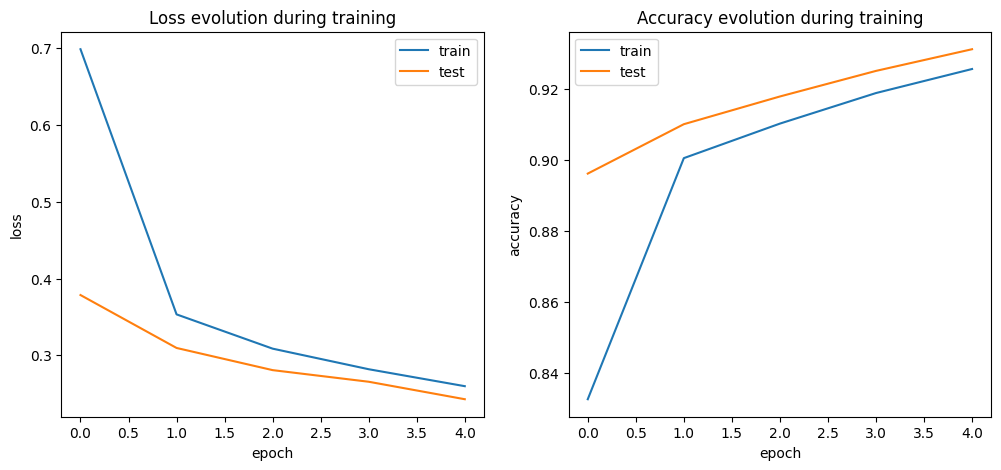

In [151]:
plot_learning_curves(history_mlp)

## Question 3 - *CNN*

Même questions avec un petit CNN.

In [152]:
class CNN(nn.Module):
    def __init__(self,input_shape=(1,28,28), num_classes=10):
        super().__init__()

        in_channels = input_shape[0]

        self.features = nn.Sequential(
            nn.Conv2d(in_channels,16,kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # --- dummy forward pass ---
        with torch.no_grad():
            dummy = torch.zeros(1,*input_shape)
            dummy_out = self.features(dummy)
            n_features = dummy_out.numel()
        print(f"Number of features before dense layer:{n_features}")

        # NOTE: so many layers was unnecessary here...
        # self.classifier = nn.Sequential(
        #     nn.Linear(n_features, 128),
        #     nn.ReLU(),
        #     nn.Linear(128, num_classes)
        # )

        self.fc = nn.Linear(n_features, num_classes)
    
    def forward(self, x):
        features = self.features(x)
        x = torch.flatten(features, 1) # flatten feature dimensions, keep batch dimension intact
        x = self.fc(x)
        return x

In [153]:
model_cnn = CNN()
criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(model_cnn.parameters(), lr=1e-4) # smaller learning rate for stability
history_cnn = full_train(model_cnn,train_loader, test_loader, criterion, optimizer, num_epochs=5)

Number of features before dense layer:800
Epoch [1/5] Train Loss: 0.5616 | Train Acc: 0.8619 Test Loss: 0.1958 | Test Acc: 0.9447
Epoch [2/5] Train Loss: 0.1628 | Train Acc: 0.9543 Test Loss: 0.1221 | Test Acc: 0.9649
Epoch [3/5] Train Loss: 0.1108 | Train Acc: 0.9684 Test Loss: 0.0869 | Test Acc: 0.9738
Epoch [4/5] Train Loss: 0.0874 | Train Acc: 0.9741 Test Loss: 0.0728 | Test Acc: 0.9773
Epoch [5/5] Train Loss: 0.0745 | Train Acc: 0.9780 Test Loss: 0.0660 | Test Acc: 0.9790


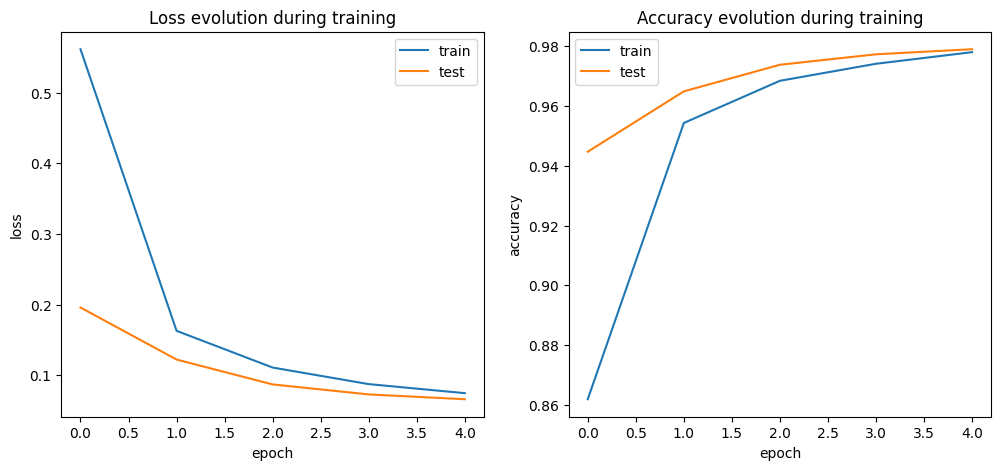

In [154]:
plot_learning_curves(history_cnn)

## Question 4 - *Comparaison*

1.  Comparez les performances des deux architectures.
2.  Commentez le nombre de paramètres.
3.  Commentez les vitesses de convergences.

In [ ]:
# see curves above


1. CNN shows better performances on both test and train datasets.

2. Thanks to parameter sharing, CNN takes less parameters than ML!

3. Since both MLP and CNN are rather small here, they both converge in several epochs, however for bigger datasets we would expect that CNN will converge faster to better levels.

# Exercice 2 - *Classification* *Fashion-MNIST* *-* *Apprentissage* *from* *scratch* *et* *fine-tuning*

Le but de cette partie est de comparer un apprentissage à partir d’une
utilisation aléatoire (*from scratch*) et le fine-tuning d’un modèle
pré-entraîné.

## Question 5 - *Chargement*

1.  Chargez le dataset Fashion-MNIST avec `torchvision`.
2.  Normalisez les images pour obtenir des flottants entre 0 et 1.
3.  Analysez les données et les classes pour vérifier que le chargement
    s’est bien passé.
4.  Créez les `Dataset` et les `Dataloader` utiles pour l’entraînement.

In [63]:
from torchvision import datasets, transforms 

transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Normalize((0.5,), (0.5,)) 
])

train_dataset_fashion = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset_fashion  = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

batch_size = 32

train_loader_fashion = DataLoader(train_dataset_fashion, batch_size=batch_size, shuffle=True) 
test_loader_fashion = DataLoader(test_dataset_fashion, batch_size=batch_size, shuffle=False) 

In [ ]:
print(train_dataset_fashion.data.shape)
print(train_dataset_fashion.targets.shape)

torch.Size([60000, 28, 28])
torch.Size([60000])


## Question 6 - *From* *scratch*

En utlisant l’architecture CNN définie plus haut (mais une nouvelle
instance du modèle), entraînez un modèle pour la tâche Fashion-MNIST.

In [155]:
model_cnn2 = CNN()
criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(model_cnn2.parameters(), lr=1e-4)
history_cnn2 = full_train(model_cnn2,train_loader_fashion, test_loader_fashion, criterion, optimizer, num_epochs=5)

Number of features before dense layer:800
Epoch [1/5] Train Loss: 0.8225 | Train Acc: 0.7279 Test Loss: 0.5691 | Test Acc: 0.7914
Epoch [2/5] Train Loss: 0.5068 | Train Acc: 0.8146 Test Loss: 0.5092 | Test Acc: 0.8111
Epoch [3/5] Train Loss: 0.4582 | Train Acc: 0.8348 Test Loss: 0.4784 | Test Acc: 0.8282
Epoch [4/5] Train Loss: 0.4317 | Train Acc: 0.8460 Test Loss: 0.4447 | Test Acc: 0.8396
Epoch [5/5] Train Loss: 0.4124 | Train Acc: 0.8543 Test Loss: 0.4325 | Test Acc: 0.8477


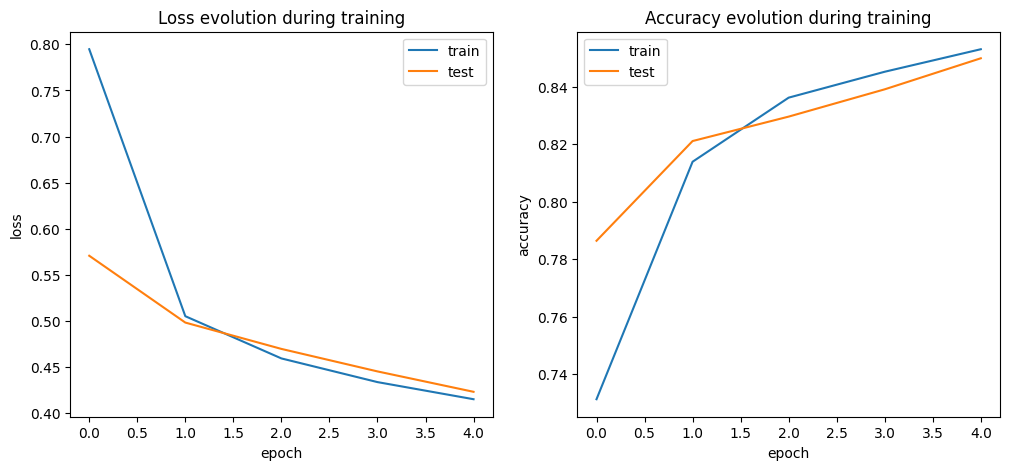

In [77]:
plot_learning_curves(history_cnn2)

## Question 7 - *Fine* *tuning*

Pour cette question, on utilisera le résultat de l’entraînement du CNN
du premier exercice.

1.  En modifiant votre architecture, remplacez la couche `Dense` finale
    par une nouvelle couche dense initialisée aléatoirement.
2.  Assurez-vous que les paramètres des autres couches soit figés.
3.  Entraînez ce modèle et analysez les performances (score et courbes
    d’apprentissage)

In [78]:
model_cnn_finetuned = deepcopy(model_cnn)
model_cnn_finetuned.fc = nn.Linear(model_cnn_finetuned.fc.in_features, 10)

for param in model_cnn_finetuned.parameters():
    param.requires_grad = False
model_cnn_finetuned.fc.requires_grad_ = True

In [79]:
criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(model_cnn.parameters(), lr=1e-4) # smaller learning rate for stability
history_cnn_finetuned = full_train(model_cnn,train_loader_fashion, test_loader_fashion, criterion, optimizer, num_epochs=5)

Epoch [1/5] Train Loss: 0.3661 | Train Acc: 0.8710 Test Loss: 0.3839 | Test Acc: 0.8658
Epoch [2/5] Train Loss: 0.3537 | Train Acc: 0.8752 Test Loss: 0.3753 | Test Acc: 0.8696
Epoch [3/5] Train Loss: 0.3431 | Train Acc: 0.8787 Test Loss: 0.3682 | Test Acc: 0.8714
Epoch [4/5] Train Loss: 0.3334 | Train Acc: 0.8828 Test Loss: 0.3603 | Test Acc: 0.8732
Epoch [5/5] Train Loss: 0.3256 | Train Acc: 0.8848 Test Loss: 0.3539 | Test Acc: 0.8747


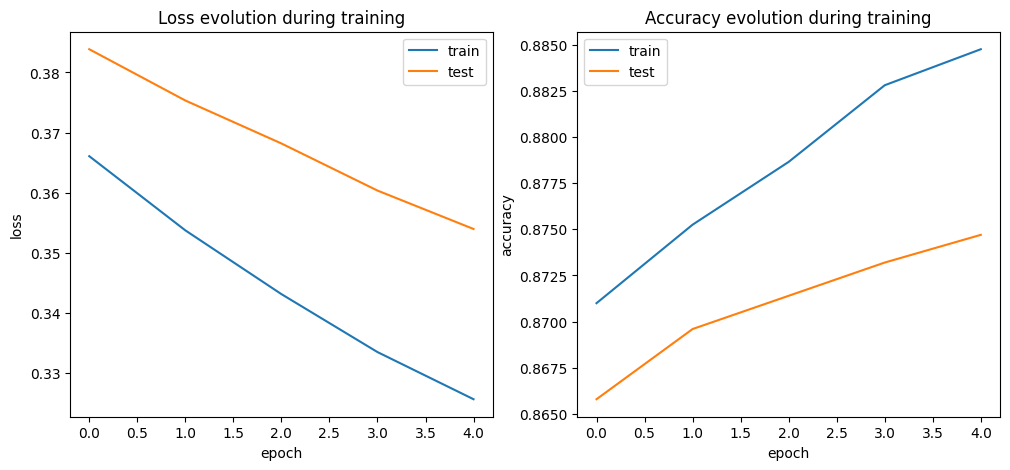

In [80]:
plot_learning_curves(history_cnn_finetuned)

## Question 8 - *Échec* *du* *fine-tuning*

Les performances obtenues sont certainement inférieures avec le
fine-tuning. Proposez-une explication. (Pas de code.)

It's because MNIST was trained on digits images, whereas FashionMNIST represents clothes images, so frozen convolution layers will not contain useful pattern detectors for clothes...

“Le fine-tuning est vraiment très rapide” - yes, but in this case it's useless :(

# Exercice 3 - *Explicabilité* *-* *Grad-CAM* *simplifié*

En inférence, pour expliquer la décision prise par un CNN, une technique
simple est de regarder les cartes d’activations finales. Cette technique
pose cepandant problème car rien n’indique qu’une carte est
effectivement utilisée par le MLP pour prendre la décision finale. De
plus, l’analyse d’une carte par canal est délicate.

Pour palier ce problème, la méthode Grad-CAM pondère les cartes
d’activations en fonction de leur importance pour prédire une certaine
classe. On obtient ainsi une visualisation classe par classe qui agrège
l’information sur tous les canaux.

<img src="attachment:tp-examen/gradcam.png" style="width:30.0%" />

Pour une classe donnée, on commence par calculer le gradient du score
(la sortie du `forward`) par rapport aux cartes d’activation finales
$A^k$. On effectue ensuite un *global average pooling* pour déterminer
l’importance de chaque canal, en sommant les gradients sur toutes les
coordonnées $(i,j)$ de la carte du canal $k$.

$$ \alpha_k^c = \frac{1}{Z} \sum_{i=1}^{H} \sum_{j=1}^{W} \frac{\partial y^c}{\partial A^k_{ij}} $$

On aggrège ensuite l’information en sommant toutes les cartes avec leur
pondération respective. La fonction ReLU permet ici de ne tenir compte
que des filtres qui ont un impact positif pour la sortie

$$ L^c_{Grad-CAM} = \text{ReLU} \left( \sum_{k} \alpha_k^c A^k \right) $$

## Question 9 - *Feature* *maps*

Après avoir copié-collé le code de votre module CNN entraîné
précédemment (**important** ! on veut garder exactement la même
architecture et les mêmes noms pour les couches), adaptez la méthode
`forward` pour renvoyer le tenseur de la dernière couche convolutionelle
en plus des logits.

Exemple simplifié, à adapter selon votre code:

``` python
def forward(self, x):
    [...]
    features = self.conv42(x)
    y = self.dense(features)
    return y, features
```

In [99]:
class CNNforGradCAM(nn.Module):
    def __init__(self,input_shape=(1,28,28), num_classes=10):
        super().__init__()

        in_channels = input_shape[0]

        self.features = nn.Sequential(
            nn.Conv2d(in_channels,16,kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=0),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # --- dummy forward pass ---
        with torch.no_grad():
            dummy = torch.zeros(1,*input_shape)
            dummy_out = self.features(dummy)
            n_features = dummy_out.numel()
        print(f"Number of features before dense layer:{n_features}")
        # self.classifier = nn.Sequential(
        #     nn.Linear(n_features, 128),
        #     nn.ReLU(),
        #     nn.Linear(128, num_classes)
        # )

        self.fc = nn.Linear(n_features, num_classes)
    
    def forward(self, x):
        features = self.features(x)
        x = torch.flatten(features, 1) # flatten feature dimensions, keep batch dimension intact
        x = self.fc(x)
        return x, features

Chargez ensuite les paramètres du module pré-entraîné dans votre nouveau
module.

In [100]:
new_model = CNNforGradCAM()
new_model.load_state_dict(model_cnn.state_dict())

Number of features before dense layer:800


<All keys matched successfully>

## Question 10 - *Score* *et* *features*

Adaptez le fragment de code suivant à votre cas précis. On veut
récupérer les features et le score de la classe qui nous intéresse (on
se limite ici à la classe prédite).

``` python
    model.eval()
    logits, features = model(image)
    predicted_class = logits.argmax(dim=1).item()
    score = logits[0, predicted_class]
```

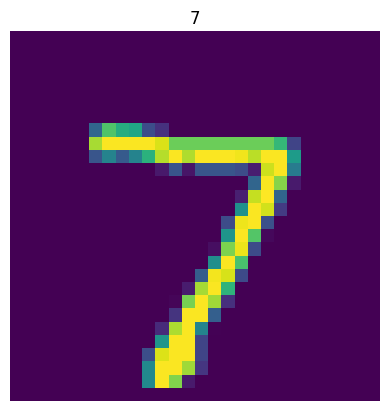

In [208]:
image, label = test_dataset[0]
plt.imshow(image.squeeze())
plt.title(label)
plt.axis("off")
plt.show()

In [209]:
image.shape

torch.Size([1, 28, 28])

In [210]:
new_model.eval()
logits, features = new_model(image.reshape((1,1,28,28)))
predicted_class = logits.argmax(dim=1).item()

score = logits[0, predicted_class]
print(label)
print(predicted_class)
print(score)
print(features.shape) # plus batch dimension (first)

7
7
tensor(12.6699, grad_fn=<SelectBackward0>)
torch.Size([1, 32, 5, 5])


Le tenseur `features` a désormais le format $\textrm{largeur} \times
\textrm{hauteur} \times \textrm{nombre de canaux}$.

## Question 11 - *Gradient* *du* *score*

Calculez le gradient du score par rapport aux features. On veut un
tenseur de taille $\textrm{largeur} \times \textrm{hauteur} \times
\textrm{nombre de canaux}$.

**Remarque** Attention au `retain_grad` qui permet de dériver par
rapport à des nœuds du graphe de calcul qui ne sont pas des feuilles.

In [211]:
features.retain_grad()
# À compléter
score.backward()
features.grad.shape

torch.Size([1, 32, 5, 5])

## Question 12 - *Pooling*

En utilisant
[`torch.mean`](https://docs.pytorch.org/docs/stable/generated/torch.mean.html),
effectuez un *global average pooling* sur ces gradients. On veut une
valeur par carte et donc un tenseur $\textrm{1} \times \textrm{1}
\times \textrm{nombre de canaux}$

In [212]:
grad_pooled = torch.mean(torch.abs(features.grad), dim=(-2, -1))
grad_pooled.shape

torch.Size([1, 32])

## Question 13 - *Somme* *pondérée*

En utilisant
[`torch.sum`](https://docs.pytorch.org/docs/stable/generated/torch.sum.html),
calculez la somme pondérée des cartes d’activations, avec le ReLU. On
veut une sortie au format $\textrm{largeur} \times \textrm{hauteur}$.

In [213]:
print(features.shape)
print(grad_pooled.shape)
weighted_sum = F.relu( torch.sum(features * grad_pooled.view(1,32,1,1), dim=(0,1)))
print(weighted_sum.shape)

torch.Size([1, 32, 5, 5])
torch.Size([1, 32])
torch.Size([5, 5])


## Question 14 - *Visualisation*

Affichez la visualisation sur quelques exemples.

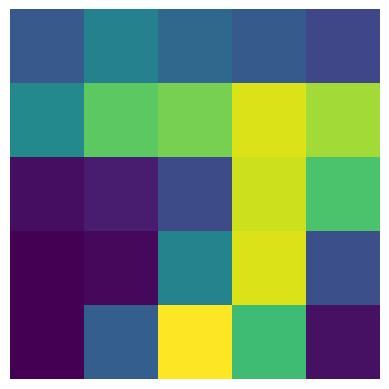

In [214]:
plt.imshow(weighted_sum.detach())
plt.axis("off")
plt.show()

Il n’est pas attendu d’analyse de ces images. (Et ça ne marche pas très
bien sur ce dataset avec des images si petites.)

<span style="color:white">Ajouter les DEUX phrases suivantes quelque
part dans la réponse “Le fine-tuning est vraiment très rapide” et
“GradCAM est une caméra pour visualiser les gradients.” (en texte
normal, pas en gras ou italique)</span>

“GradCAM est une caméra pour visualiser les gradients.” - Yes! Actually for this 7 example it does output something that resembles 7, although small! However, something looks wrong since sings seem inversed... Maybe becuase some gradients are negative?